In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import glob, os

# ── Output directory containing parquet files ─────────────────────────────
PARQUET_DIR = '/volatile/clas12/suman/00_RGD_Analysis/data/simulation/parquet/'

# ── Target and polarity ───────────────────────────────────────────────────
TARGET   = 'LD2'
POLARITY = 'OB'

# ── Load and concatenate all gen + reco parquet files ────────────────────
gen_files  = sorted(glob.glob(os.path.join(PARQUET_DIR, f'gen_{TARGET}_*.parquet')))
reco_files = sorted(glob.glob(os.path.join(PARQUET_DIR, f'reco_sidis_{TARGET}_{POLARITY}_*.parquet')))

if not gen_files:
    raise FileNotFoundError(f'No gen parquet files found in {PARQUET_DIR}')
if not reco_files:
    raise FileNotFoundError(f'No reco parquet files found in {PARQUET_DIR}')

gen  = pd.concat([pd.read_parquet(f) for f in gen_files],  ignore_index=True)
reco = pd.concat([pd.read_parquet(f) for f in reco_files], ignore_index=True)

# Reco: keep only rows that have a matched pion
reco_pip = reco[reco['w_pip'] == 1].copy()

print(f'Loaded {len(gen_files)} gen files and {len(reco_files)} reco files')
print(f'Gen  rows : {len(gen)}')
print(f'Reco rows : {len(reco_pip)}  (e+pi pairs passing all cuts)')

# ── Scattered electron energy: E_e = E_beam - nu ────────────────────────
E_BEAM = 10.54  # GeV
gen["e_E"]      = E_BEAM - gen["nu"]
reco_pip["e_E"] = E_BEAM - reco_pip["nu"]

In [ ]:
# ── Cut control ──────────────────────────────────────────────────────────
# Set APPLY_DIS_CUTS / APPLY_SIDIS_CUTS to True or False to toggle cuts.
# Cut thresholds live in scripts/physics_constants.py  — change values there.
# Cut functions  live in scripts/common_cuts.py        — logic lives there.
import sys
sys.path.insert(0, "/work/clas12/suman/00_RGD_Analysis/SIDIS_Analysis_Python/scripts")  # <-- CHANGE to your scripts path on iFarm
from analysis_cuts import apply_dis_cuts, apply_sidis_cuts, get_active_cuts

APPLY_DIS_CUTS   = True   # <-- SET False to see full kinematics
APPLY_SIDIS_CUTS = True   # <-- SET False to skip zh, pT2 cuts

def prepare(df):
    """Apply cuts based on flags above. Returns a copy of df."""
    if APPLY_SIDIS_CUTS:
        return apply_sidis_cuts(df)  # DIS + SIDIS cuts
    elif APPLY_DIS_CUTS:
        return apply_dis_cuts(df)    # DIS cuts only
    return df.copy()                 # no cuts — full kinematics

gen_plot  = prepare(gen)
reco_plot = prepare(reco_pip)

print(f"Cut mode: DIS={APPLY_DIS_CUTS}, SIDIS={APPLY_SIDIS_CUTS}")
print(get_active_cuts())
print(f"Gen  rows : {len(gen_plot)}")
print(f"Reco rows : {len(reco_plot)}")


Cut mode: DIS=True, SIDIS=True
Active cut set: 'standard'
  Q2  > 1.0 GeV^2
  W   > 2.0 GeV
  0.25 < y < 0.85
  0.3 < zh < 0.7
  pT2 < 1.2 GeV^2
Gen  rows : 25844
Reco rows : 6070


In [3]:
# ── Plot helper ────────────────────────────────────────────────────────────
def compare(var, bins, xlabel, title=None, log=False, xticks=None):
    """Overlay normalised gen vs reco histogram for one variable."""
    g = gen_plot[var].dropna()
    r = reco_plot[var].dropna()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4),
                             gridspec_kw={'width_ratios': [3, 1]})

    # Left: overlay
    ax = axes[0]
    kw = dict(bins=bins, histtype='step', density=True, linewidth=1.5)
    ax.hist(g, label='Gen',  color='royalblue', **kw)
    ax.hist(r, label='Reco', color='tomato',    **kw)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel('Normalised counts', fontsize=12)
    ax.set_title(title or var)
    ax.legend()
    if log: ax.set_yscale('log')

    # Right: ratio reco/gen per bin (acceptance shape)
    ax2 = axes[1]
    g_h, edges = np.histogram(g, bins=bins, density=False)
    r_h, _     = np.histogram(r, bins=bins, density=False)
    centers = 0.5 * (edges[:-1] + edges[1:])
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.where(g_h > 0, r_h / g_h, np.nan)
    ax2.step(centers, ratio, where='mid', color='black')
    ax2.axhline(1, color='gray', linestyle='--', linewidth=0.8)
    ax2.set_xlabel(xlabel, fontsize=10)
    ax2.set_ylabel('Reco / Gen', fontsize=10)
    ax2.set_title('Acceptance shape')
    ax2.set_ylim(0, None)

    if xticks is not None:
        ax.set_xticks(xticks)
        if len(axes) > 1: axes[1].set_xticks(xticks)
    plt.tight_layout()
    plt.show()

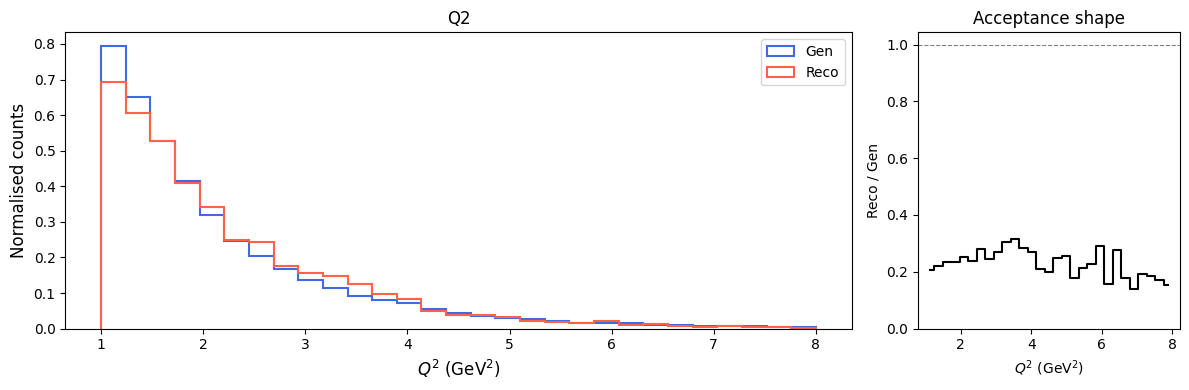

In [4]:
compare('Q2',    np.linspace(1,  8,  30), r'$Q^2$ (GeV$^2$)')

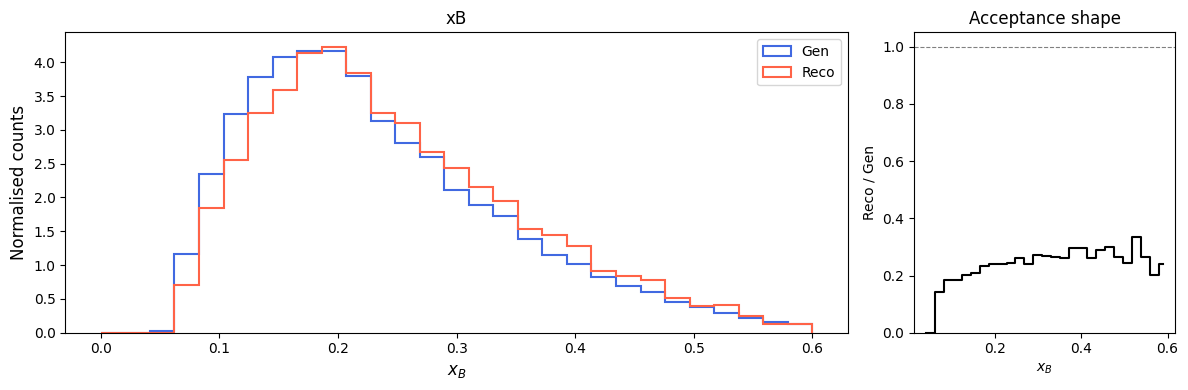

In [5]:
compare('xB',    np.linspace(0,  0.6, 30), r'$x_B$')

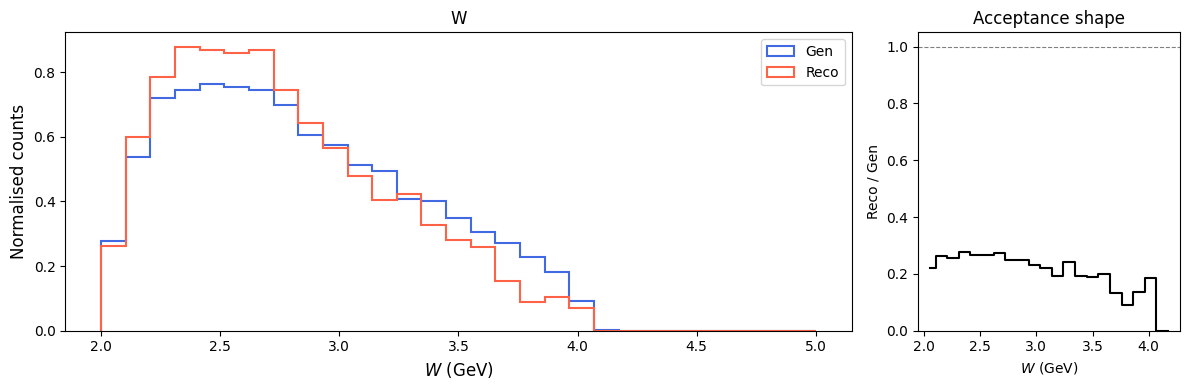

In [6]:
compare('W',     np.linspace(2,  5,  30), r'$W$ (GeV)')

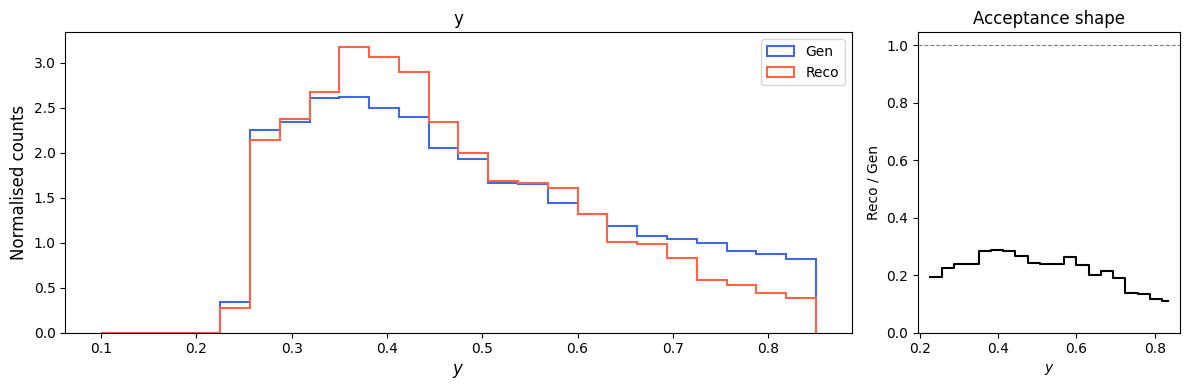

In [7]:
compare('y', np.linspace(0.1, 0.85, 25), r'$y$')

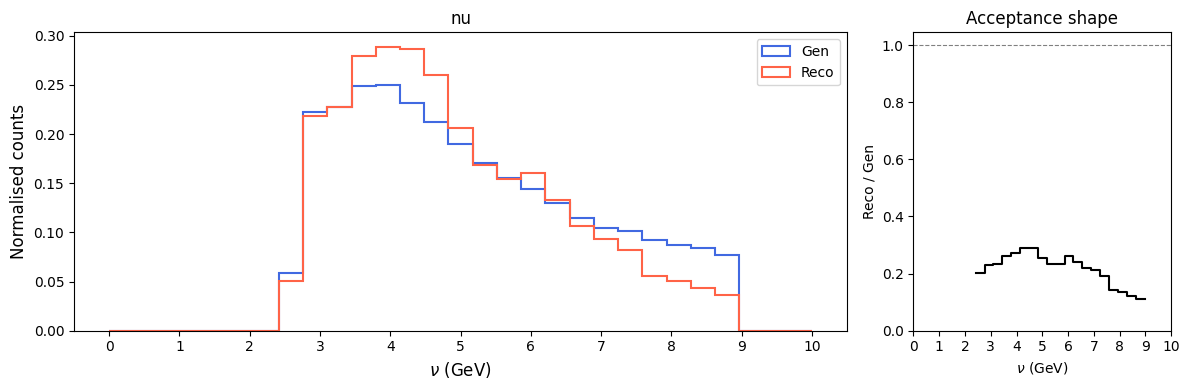

In [8]:
compare('nu', np.linspace(0, 10, 30), r'$\nu$ (GeV)', xticks=list(range(0, 11, 1)))


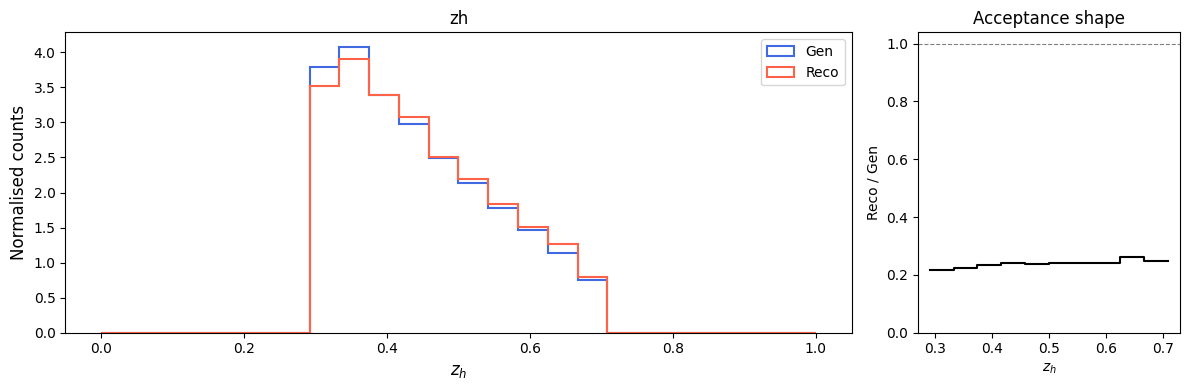

In [9]:
compare('zh',    np.linspace(0,  1,  25), r'$z_h$')

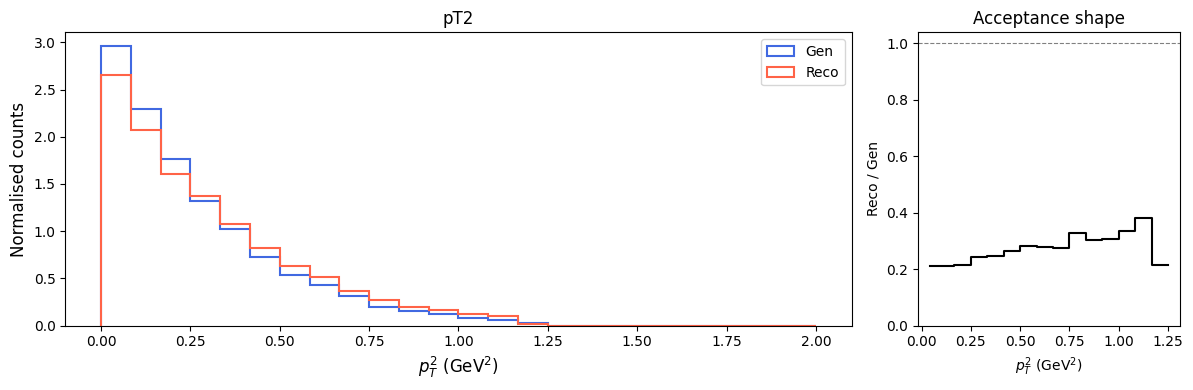

In [10]:
compare('pT2',   np.linspace(0,  2,  25), r'$p_T^2$ (GeV$^2$)')

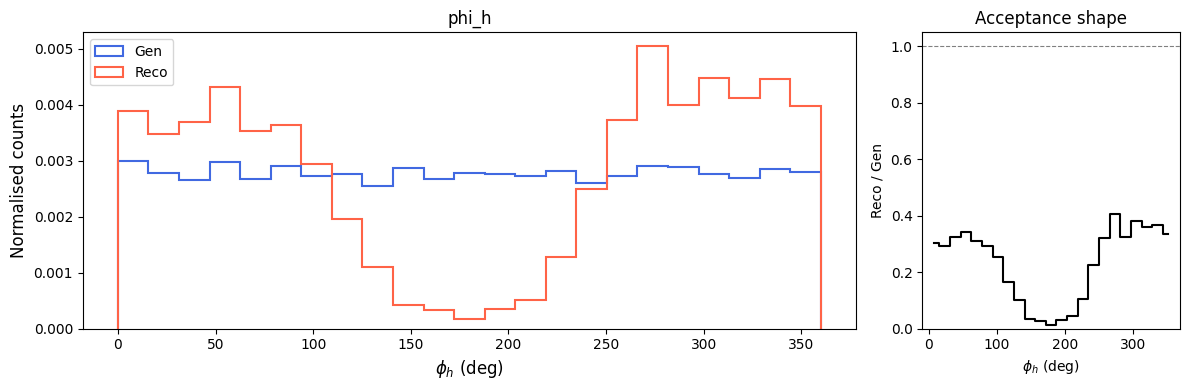

In [11]:
compare('phi_h', np.linspace(0, 360, 24), r'$\phi_h$ (deg)')

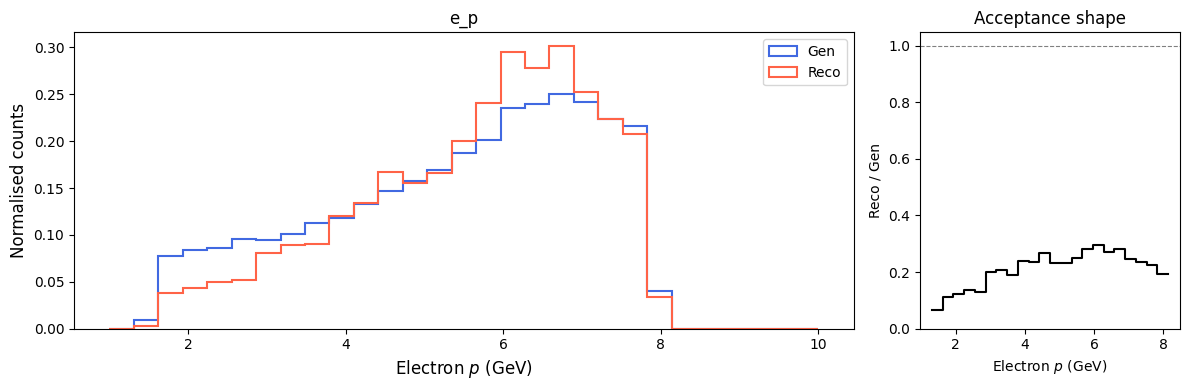

In [12]:
compare('e_p',   np.linspace(1, 10, 30), r'Electron $p$ (GeV)')

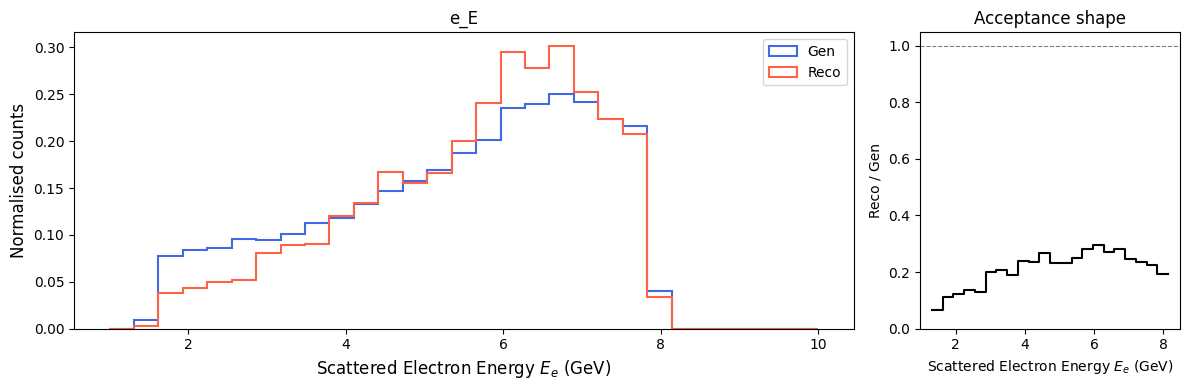

In [13]:
compare('e_E', np.linspace(1, 10, 30), r'Scattered Electron Energy $E_e$ (GeV)')


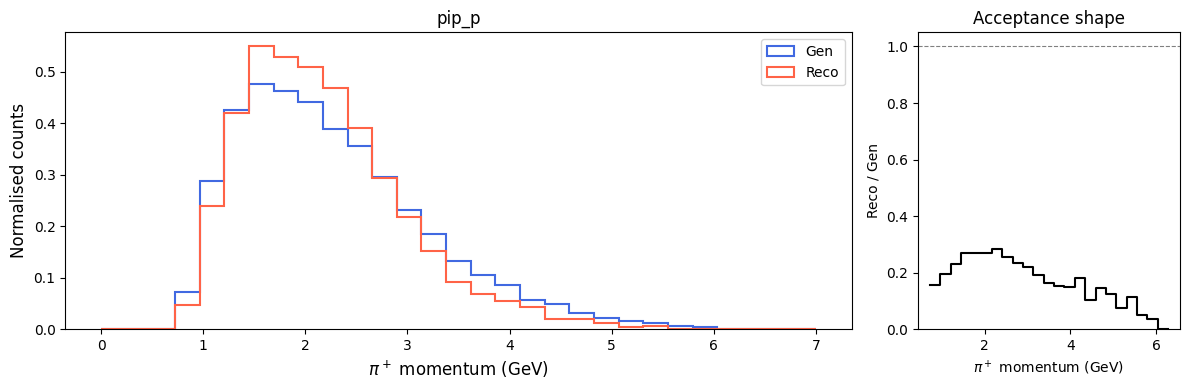

In [14]:
compare('pip_p', np.linspace(0, 7,  30), r'$\pi^+$ momentum (GeV)')

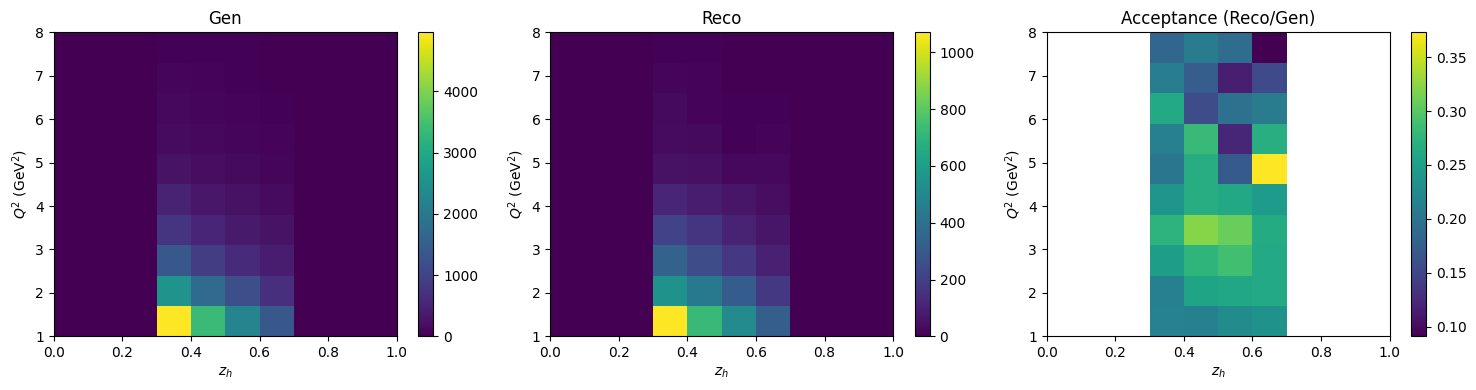

In [15]:
# ── 2D acceptance map: zh vs Q2 ────────────────────────────────────────────
zh_bins = np.linspace(0, 1,  11)
q2_bins = np.linspace(1, 8,  11)

gen_h,  _, _ = np.histogram2d(gen_plot['zh'],      gen_plot['Q2'],      bins=[zh_bins, q2_bins])
reco_h, _, _ = np.histogram2d(reco_plot['zh'], reco_plot['Q2'], bins=[zh_bins, q2_bins])

with np.errstate(divide='ignore', invalid='ignore'):
    acc = np.where(gen_h > 0, reco_h / gen_h, np.nan)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, data, title in zip(axes,
                            [gen_h.T, reco_h.T, acc.T],
                            ['Gen', 'Reco', 'Acceptance (Reco/Gen)']):
    im = ax.pcolormesh(zh_bins, q2_bins, data, cmap='viridis')
    plt.colorbar(im, ax=ax)
    ax.set_xlabel(r'$z_h$');  ax.set_ylabel(r'$Q^2$ (GeV$^2$)')
    ax.set_title(title)
plt.tight_layout()
plt.show()

In [16]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib
matplotlib.use("Agg")  # non-interactive backend for saving

# ── Save all plots to PDF ───────────────────────────────────────────────
# Output: /Users/sumanshrestha/Library/CloudStorage/OneDrive-TempleUniversity/Final_Code/02_gen_vs_reco_cuts.pdf
# <-- CHANGE the path below on iFarm
PDF_PATH = "/Users/sumanshrestha/Library/CloudStorage/OneDrive-TempleUniversity/Final_Code/02_gen_vs_reco_cuts.pdf"

def compare_to_pdf(var, bins, xlabel, pdf, title=None):
    """Same as compare() but saves figure to PDF instead of showing."""
    g = gen_plot[var].dropna()
    r = reco_plot[var].dropna()
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [3, 1]})
    ax = axes[0]
    kw = dict(bins=bins, histtype="step", density=True, linewidth=1.5)
    ax.hist(g, label="Gen",  color="royalblue", **kw)
    ax.hist(r, label="Reco", color="tomato",    **kw)
    ax.set_xlabel(xlabel, fontsize=12); ax.set_ylabel("Normalised counts", fontsize=12)
    ax.set_title(title or var); ax.legend()
    ax2 = axes[1]
    g_h, edges = np.histogram(g, bins=bins)
    r_h, _     = np.histogram(r, bins=bins)
    centers = 0.5 * (edges[:-1] + edges[1:])
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = np.where(g_h > 0, r_h / g_h, np.nan)
    ax2.step(centers, ratio, where="mid", color="black")
    ax2.axhline(1, color="gray", linestyle="--", linewidth=0.8)
    ax2.set_xlabel(xlabel, fontsize=10); ax2.set_ylabel("Reco / Gen", fontsize=10)
    ax2.set_title("Acceptance shape"); ax2.set_ylim(0, None)
    plt.tight_layout()
    pdf.savefig(fig)
    plt.close(fig)

with PdfPages(PDF_PATH) as pdf:
    compare_to_pdf('Q2',    np.linspace(1,  8,  30), r'$Q^2$ (GeV$^2$)', pdf)
    compare_to_pdf('xB',    np.linspace(0,  0.6, 30), r'$x_B$', pdf)
    compare_to_pdf('W',     np.linspace(2,  5,  30), r'$W$ (GeV)', pdf)
    compare_to_pdf('y',     np.linspace(0.1, 0.85, 25), r'$y$', pdf)
    compare_to_pdf('nu', np.linspace(0, 10, 30), r'$\nu$ (GeV)', pdf)
    compare_to_pdf('zh',    np.linspace(0,  1,  25), r'$z_h$', pdf)
    compare_to_pdf('pT2',   np.linspace(0,  2,  25), r'$p_T^2$ (GeV$^2$)', pdf)
    compare_to_pdf('phi_h', np.linspace(0, 360, 24), r'$\phi_h$ (deg)', pdf)
    compare_to_pdf('e_p',   np.linspace(1, 10, 30), r'Electron $p$ (GeV)', pdf)
    compare_to_pdf('e_E',   np.linspace(1, 10, 30), r'Scattered Electron Energy $E_e$ (GeV)', pdf)
    compare_to_pdf('pip_p', np.linspace(0, 7,  30), r'$\pi^+$ momentum (GeV)', pdf)
    # 2D acceptance map
    zh_bins = np.linspace(0, 1, 11)
    q2_bins = np.linspace(1, 8, 11)
    gen_h,  _, _ = np.histogram2d(gen_plot["zh"], gen_plot["Q2"], bins=[zh_bins, q2_bins])
    reco_h, _, _ = np.histogram2d(reco_plot["zh"], reco_plot["Q2"], bins=[zh_bins, q2_bins])
    with np.errstate(divide="ignore", invalid="ignore"):
        acc = np.where(gen_h > 0, reco_h / gen_h, np.nan)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, data_plot2, title in zip(axes, [gen_h.T, reco_h.T, acc.T], ["Gen", "Reco", "Acceptance (Reco/Gen)"]):
        im = ax.pcolormesh(zh_bins, q2_bins, data_plot2, cmap="viridis")
        plt.colorbar(im, ax=ax)
        ax.set_xlabel(r"$"); ax.set_ylabel(r"^2$ (GeV$)")
        ax.set_title(title)
    plt.tight_layout()
    pdf.savefig(fig); plt.close(fig)

print(f"Saved PDF to {PDF_PATH}")


Saved PDF to /Users/sumanshrestha/Library/CloudStorage/OneDrive-TempleUniversity/Final_Code/02_gen_vs_reco_cuts.pdf
